# SVGP two-stage double-check (100 reps) — A1 x-normalization + y z-score

This notebook runs **double-check** for **rep000–rep099**. For each replication, it:

1. Reads `pointwise_coverage_repXXX_A*_B*.csv` (the calibration dictionary).
2. Computes **alpha\*(x\_j)** at each test point (largest alpha meeting target coverage, else max coverage).
3. Reconstructs the **fixed global training pool** (drawn once) and trains:
   - **Stage-1** (α=1): hyperparameters + variational mean
   - **Stage-2** (α=alpha\*): covariance-only with β=1/α
4. Writes **one CSV per rep**: `rep_XXX_doublecheck.csv`.

## Alignment with your updated experiment
- **x normalization (A1 / mentor-style):** min-max to [0,1] then map to [-1,1] (train/test/Z share the same transform).
- **y standardization:** Z-score **before training**; predictions are **de-standardized** back to raw y for coverage/MSE.
- **noise nugget:** `noise_raw` is in raw y units; converted to standardized space via `noise_std = noise_raw / (y_std**2)`.
- **CI quantile:** uses `ci_level` to compute `z_ci = Φ^{-1}((1+ci_level)/2)` (not hard-coded 1.96).
- **training inputs:** x-train pool is drawn **once** globally; each rep uses the same pool (no re-draw).

> Edit the two paths in the next cell (`CALIB_DIR`, `OUT_DIR`) before running.


In [1]:
# ---- USER PATHS (edit these) ----
CALIB_DIR = r"C:\Users\yangy\26 spring\double check"   # directory containing pointwise_coverage_repXXX_A*_B*.csv
OUT_DIR   = r"C:\Users\yangy\26 spring\double check\doublecheck_outputs"  # where rep_XXX_doublecheck.csv will be written

# Optional: limit reps for a quick smoke test
REP_IDS = list(range(100))  # e.g. [54] or list(range(5))


In [2]:
import os, math, time, glob
from dataclasses import dataclass
from contextlib import ExitStack

import numpy as np
import pandas as pd

import torch
import gpytorch
from torch.utils.data import DataLoader, TensorDataset


In [3]:
# ---------- logging / utils ----------
def now(): return time.strftime("%H:%M:%S")
def log(msg): print(f"[{now()}] {msg}", flush=True)

def has_setting(name: str) -> bool:
    return hasattr(gpytorch.settings, name)

def ciq_context():
    # kept for compatibility; default use_ciq=False
    stack = ExitStack()
    for name, val in [
        ("num_contour_quadrature", 15),
        ("ciq_samples", 16),
        ("ciq_max_iter", 30),
        ("ciq_forward_precision", 0.01),
        ("eval_cg_tolerance", 1e-4),
        ("max_root_decomposition_size", 64),
    ]:
        if has_setting(name):
            stack.enter_context(getattr(gpytorch.settings, name)(val))
    stack.enter_context(gpytorch.settings.fast_pred_var(True))
    return stack

def clone_state_dict(sd):
    out = {}
    for k, v in sd.items():
        out[k] = v.detach().clone() if torch.is_tensor(v) else v
    return out


In [4]:
# ---------- DGP ----------
def f0(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(2 * math.pi * x) + 0.5 * torch.cos(3 * x)

def make_stratified_points_1d(n, low, high, generator, device, dtype):
    i = torch.arange(n, device=device, dtype=dtype)
    u = (i + torch.rand(n, generator=generator, device=device, dtype=dtype)) / n
    x = low + (high - low) * u
    perm = torch.randperm(n, generator=generator, device=device)
    return x[perm].unsqueeze(-1)


In [5]:
# ---------- config (match your updated pointwise code) ----------
@dataclass
class CFG:
    # data
    n_train: int = 500
    n_test: int = 50
    train_low: float = -2.5
    train_high: float = 2.5
    test_low: float = -2.5
    test_high: float = 2.5

    # model / training
    use_fp64: bool = True
    use_ciq: bool = False
    inducing_points: int = 50
    stage1_epochs: int = 5000
    stage2_epochs: int = 1500
    batch_size: int = 500
    lr_adam_stage1: float = 2e-2
    lr_adam_stage2: float = 2e-2
    jitter: float = 1e-2
    seed: int = 13  # base seed

    # nugget in RAW y units (will be converted to standardized y space)
    noise_raw: float = 3e-3

    # early stopping Stage-1
    early_stop_patience: int = 60
    early_stop_min_delta: float = 1e-4

    # target CI level
    ci_level: float = 0.95

cfg = CFG()


In [6]:
# ---------- SVGP model ----------
class SVGPModel(gpytorch.models.ApproximateGP):
    def __init__(self, inducing_points_std: torch.Tensor):
        M = inducing_points_std.size(0)
        q_dist = gpytorch.variational.CholeskyVariationalDistribution(M)
        q_strat = gpytorch.variational.VariationalStrategy(
            self, inducing_points_std, q_dist, learn_inducing_locations=False
        )
        super().__init__(q_strat)
        self.mean_module = gpytorch.means.ConstantMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x_std):
        mean_x = self.mean_module(x_std)
        covar_x = self.covar_module(x_std)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

def freeze_all_params(model, likelihood):
    for p in model.parameters(): p.requires_grad_(False)
    for p in likelihood.parameters(): p.requires_grad_(False)

def pick_covariance_params_svgp(model):
    trainables, names = [], []
    vdist_mod = None
    vs = getattr(model, "variational_strategy", None)
    if vs is not None:
        if hasattr(vs, "_variational_distribution"):
            vdist_mod = getattr(vs, "_variational_distribution")
        else:
            cand = getattr(vs, "variational_distribution", None)
            if isinstance(cand, torch.nn.Module):
                vdist_mod = cand

    if isinstance(vdist_mod, torch.nn.Module):
        for n, p in vdist_mod.named_parameters(recurse=True):
            low = n.lower()
            if "mean" in low:
                p.requires_grad_(False)
            elif any(k in low for k in ["chol", "std", "var", "covar", "factor"]):
                p.requires_grad_(True); trainables.append(p); names.append(f"vdist.{n}")
            else:
                p.requires_grad_(False)

    if not trainables:
        allow = (
            "chol_variational_covar","variational_distribution.chol_covar",
            "variational_distribution._cholesky_factor","_variational_distribution.chol_covar",
            "raw_covar","chol_factor","covar_factor","variational_stddev","raw_var",
            "qchol","q_scale_tril"
        )
        for n, p in model.named_parameters():
            low = n.lower()
            if "variational_strategy" in low and any(k in low for k in allow) and "mean" not in low:
                p.requires_grad_(True); trainables.append(p); names.append(n)
    return trainables, names


In [7]:
# ---------- training ----------
def stage1_train(model, likelihood, x_train_std, y_train_std, lr, epochs, jitter, batch_size,
                 early_stop_patience, early_stop_min_delta):
    N = x_train_std.size(0)
    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=1.0)

    likelihood.noise_covar.raw_noise.requires_grad_(False)
    opt = torch.optim.Adam([
        {"params": model.variational_parameters()},
        {"params": model.hyperparameters()},
        {"params": likelihood.parameters()},
    ], lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train_std),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    neg_elbo_hist, best_loss, best_epoch = [], float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())
    patience = 0

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1

            avg_loss = total / max(1, n_batches)
            neg_elbo_hist.append(avg_loss)

            if best_loss - avg_loss > early_stop_min_delta:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())
                patience = 0
            else:
                patience += 1

            if patience >= early_stop_patience:
                break

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return neg_elbo_hist, best_epoch, best_loss

def stage2_train_cov_only(model, likelihood, x_train_std, y_train_std, beta, lr, epochs, jitter, batch_size):
    N = x_train_std.size(0)
    freeze_all_params(model, likelihood)
    cov_params, cov_names = pick_covariance_params_svgp(model)
    assert cov_params, "No covariance params found to train in Stage-2."

    mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=N, beta=beta)
    opt = torch.optim.Adam(cov_params, lr=lr)

    loader = DataLoader(TensorDataset(x_train_std, y_train_std),
                        batch_size=batch_size, shuffle=True, drop_last=False)

    model.train(); likelihood.train()
    best_loss, best_epoch = float("inf"), 0
    best_model_sd = clone_state_dict(model.state_dict())
    best_lik_sd   = clone_state_dict(likelihood.state_dict())

    with gpytorch.settings.cholesky_jitter(jitter):
        for ep in range(1, epochs + 1):
            total, n_batches = 0.0, 0
            for xb, yb in loader:
                opt.zero_grad(set_to_none=True)
                out = model(xb)
                loss = -mll(out, yb)
                if loss.numel() > 1: loss = loss.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(cov_params, 5.0)
                opt.step()
                total += float(loss.item()); n_batches += 1

            avg_loss = total / max(1, n_batches)
            if avg_loss < best_loss:
                best_loss, best_epoch = avg_loss, ep
                best_model_sd = clone_state_dict(model.state_dict())
                best_lik_sd   = clone_state_dict(likelihood.state_dict())

    model.load_state_dict(best_model_sd)
    likelihood.load_state_dict(best_lik_sd)
    model.eval(); likelihood.eval()
    return best_epoch, best_loss, cov_names


In [8]:
# ---------- helpers: find per-rep calibration CSV + compute alpha* ----------
def find_calib_csv(calib_dir: str, rep_id: int) -> str:
    pat = os.path.join(calib_dir, f"pointwise_coverage_rep{rep_id:03d}_A*_B*.csv")
    matches = glob.glob(pat)
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected exactly 1 match for {pat}, found {len(matches)}.")
    return matches[0]

def compute_alpha_star_from_df(df: pd.DataFrame, target: float):
    # columns: x, alpha_...
    assert df.columns[0].lower().startswith("x")
    x_axis = df.iloc[:, 0].to_numpy()
    alpha_cols = [c for c in df.columns if c.startswith("alpha_")]
    if not alpha_cols:
        raise ValueError("No alpha_* columns found.")

    alpha_values = np.array([float(c.split('_')[1]) for c in alpha_cols], dtype=float)  # [A]
    coverage_mat = df[alpha_cols].to_numpy()  # [J, A]

    J, A = coverage_mat.shape
    alpha_star = np.zeros(J, dtype=float)
    cov_at_alpha_star = np.zeros(J, dtype=float)

    for j in range(J):
        cov_row = coverage_mat[j, :]  # [A]
        order_desc = np.argsort(alpha_values)[::-1]
        alphas_desc = alpha_values[order_desc]
        cov_desc = cov_row[order_desc]

        idx_ge = np.where(cov_desc >= target)[0]
        if idx_ge.size > 0:
            chosen_desc_idx = int(idx_ge[0])  # largest alpha meeting target
        else:
            chosen_desc_idx = int(np.argmax(cov_desc))  # max coverage

        best_idx = int(order_desc[chosen_desc_idx])
        alpha_star[j] = alpha_values[best_idx]
        cov_at_alpha_star[j] = cov_row[best_idx]

    return x_axis, alpha_values, alpha_cols, alpha_star, cov_at_alpha_star


In [9]:
# ---------- build global fixed pools (x_train, x_test, Z) and standardizers ----------
device = torch.device("cpu")  # local notebook default
torch.set_default_dtype(torch.float64 if cfg.use_fp64 else torch.float32)

# fixed global train/test pools
gen_global = torch.Generator(device=device).manual_seed(cfg.seed)
x_train_raw = make_stratified_points_1d(cfg.n_train, cfg.train_low, cfg.train_high,
                                        generator=gen_global, device=device, dtype=torch.get_default_dtype())
x_test_raw = torch.linspace(cfg.test_low, cfg.test_high, cfg.n_test,
                            device=device, dtype=torch.get_default_dtype()).unsqueeze(1)

y_train_raw = f0(x_train_raw).squeeze(-1)
y_test_true_raw = f0(x_test_raw).squeeze(-1)

# A1 x-normalization: minmax->[0,1] then ->[-1,1]
train_low_t = torch.as_tensor(cfg.train_low, device=device, dtype=torch.get_default_dtype())
train_high_t = torch.as_tensor(cfg.train_high, device=device, dtype=torch.get_default_dtype())
span = (train_high_t - train_low_t).clamp_min(1e-12)

def x_to_std(x_raw: torch.Tensor) -> torch.Tensor:
    x01 = (x_raw - train_low_t) / span
    return 2.0 * x01 - 1.0

x_train_std = x_to_std(x_train_raw)
x_test_std = x_to_std(x_test_raw)

Z_raw = torch.linspace(cfg.train_low, cfg.train_high, cfg.inducing_points,
                       device=device, dtype=torch.get_default_dtype()).unsqueeze(1)
Z_std = x_to_std(Z_raw)

left_std = float(x_to_std(torch.tensor([[cfg.train_low]], device=device, dtype=torch.get_default_dtype())))
right_std = float(x_to_std(torch.tensor([[cfg.train_high]], device=device, dtype=torch.get_default_dtype())))
log(f"A1 MinMax norm: raw [{cfg.train_low:.2f},{cfg.train_high:.2f}] -> std [{left_std:.2f},{right_std:.2f}] (≈ -1,+1)")
log(f"Z_std head/tail: {float(Z_std[0]):.3f}, {float(Z_std[-1]):.3f}")

# y z-score for training (global; since pool is fixed)
y_mean = y_train_raw.mean()
y_std = y_train_raw.std(unbiased=False).clamp_min(1e-12)
y_train_std = (y_train_raw - y_mean) / y_std

# CI quantile from ci_level
norm = torch.distributions.Normal(torch.tensor(0.0, device=device, dtype=torch.get_default_dtype()),
                                  torch.tensor(1.0, device=device, dtype=torch.get_default_dtype()))
z_ci = float(norm.icdf(torch.tensor([(1.0 + cfg.ci_level) / 2.0], device=device))[0].item())
log(f"Using z_ci={z_ci:.6f} for ci_level={cfg.ci_level:.3f}")


[23:27:34] A1 MinMax norm: raw [-2.50,2.50] -> std [-1.00,1.00] (≈ -1,+1)
[23:27:34] Z_std head/tail: -1.000, 1.000
[23:27:34] Using z_ci=1.959964 for ci_level=0.950


In [10]:
# ---------- main: run 100 reps, write per-rep CSV ----------
os.makedirs(OUT_DIR, exist_ok=True)

for rep_id in REP_IDS:
    csv_path = find_calib_csv(CALIB_DIR, rep_id)
    df = pd.read_csv(csv_path)

    # compute alpha*(x_j) from calibration dictionary
    x_axis_csv, alpha_values, alpha_cols, alpha_star, cov_at_alpha_star_calib = compute_alpha_star_from_df(
        df, target=cfg.ci_level
    )
    # sanity: ensure x grid matches our fixed x_test_raw
    x_axis_expected = x_test_raw.squeeze(-1).cpu().numpy()
    if not np.allclose(x_axis_csv, x_axis_expected, atol=1e-8, rtol=0.0):
        raise ValueError(f"x grid mismatch for rep {rep_id}: CSV x does not match expected test grid."
                        f"\nCSV head={x_axis_csv[:3]} vs expected head={x_axis_expected[:3]}")

    unique_alphas = np.unique(alpha_star)

    log(f"\n=== rep {rep_id:03d} ===")
    log(f"Read: {os.path.basename(csv_path)} | unique alpha*: {unique_alphas}")

    # build model/likelihood fresh
    model = SVGPModel(Z_std.clone().contiguous()).to(device=device)
    likelihood = gpytorch.likelihoods.GaussianLikelihood().to(device=device)

    with torch.no_grad():
        model.covar_module.base_kernel.lengthscale.fill_(1.0)
        model.covar_module.outputscale.fill_(1.0)
        # convert nugget to standardized y-space variance
        likelihood.noise = torch.as_tensor(cfg.noise_raw, device=device, dtype=torch.get_default_dtype()) / (y_std ** 2)

    likelihood.noise_covar.raw_noise.requires_grad_(False)

    # Stage-1 on full pool (standardized y)
    with (ciq_context() if cfg.use_ciq else ExitStack()):
        _, best_epoch_s1, best_loss_s1 = stage1_train(
            model, likelihood, x_train_std, y_train_std,
            lr=cfg.lr_adam_stage1, epochs=cfg.stage1_epochs, jitter=cfg.jitter,
            batch_size=cfg.batch_size,
            early_stop_patience=cfg.early_stop_patience,
            early_stop_min_delta=cfg.early_stop_min_delta
        )

    with torch.no_grad():
        pred_s1_std = model(x_test_std)
        mu_s1_raw = pred_s1_std.mean * y_std + y_mean
        mse_s1 = torch.mean((mu_s1_raw - y_test_true_raw) ** 2).item()

    log(f"[rep {rep_id:03d}] Stage-1 (α=1.000) | best -ELBO={best_loss_s1:.6f} @epoch {best_epoch_s1} | MSE={mse_s1:.6f}")

    s1_model_sd = clone_state_dict(model.state_dict())
    s1_lik_sd   = clone_state_dict(likelihood.state_dict())

    # Stage-2 for each unique alpha*, evaluate only the subset indices
    indicators = np.zeros(cfg.n_test, dtype=np.float64)

    for alpha in unique_alphas:
        idxs_np = np.where(alpha_star == alpha)[0]
        idxs_t = torch.from_numpy(idxs_np).to(device=device, dtype=torch.long)

        beta = float(1.0 / float(alpha))

        model.load_state_dict(s1_model_sd)
        likelihood.load_state_dict(s1_lik_sd)
        model.eval(); likelihood.eval()

        with (ciq_context() if cfg.use_ciq else ExitStack()):
            best_epoch_s2, best_loss_s2, _ = stage2_train_cov_only(
                model, likelihood, x_train_std, y_train_std,
                beta=beta, lr=cfg.lr_adam_stage2, epochs=cfg.stage2_epochs,
                jitter=cfg.jitter, batch_size=cfg.batch_size
            )

        with torch.no_grad():
            pred_std = model(x_test_std)
            mu_raw = pred_std.mean * y_std + y_mean
            var_raw = pred_std.variance.clamp_min(1e-24) * (y_std ** 2)
            std_raw = var_raw.sqrt().clamp_min(1e-12)

            lower = mu_raw[idxs_t] - z_ci * std_raw[idxs_t]
            upper = mu_raw[idxs_t] + z_ci * std_raw[idxs_t]
            y_sel = y_test_true_raw[idxs_t]

            cover = ((y_sel >= lower) & (y_sel <= upper)).to(torch.float64)
            indicators[idxs_np] = cover.cpu().numpy()

            mse = torch.mean((mu_raw - y_test_true_raw) ** 2).item()

        log(f"[rep {rep_id:03d}] α={float(alpha):.4f} (Stage-2) | best -ELBO={best_loss_s2:.6f} @epoch {best_epoch_s2} | MSE={mse:.6f} | num_points={len(idxs_np)}")

    # write per-rep CSV
    out_csv = os.path.join(OUT_DIR, f"rep_{rep_id:03d}_doublecheck.csv")
    df_out = pd.DataFrame({
        "x": x_axis_csv,
        "alpha_star": alpha_star,
        "cov_indicator": indicators,
        "cov_at_alpha_star_calib": cov_at_alpha_star_calib,
    })
    df_out.to_csv(out_csv, index=False)
    log(f"Saved: {out_csv}")

log("\nAll done.")


[23:27:34] 
=== rep 000 ===
[23:27:34] Read: pointwise_coverage_rep000_A7_B500.csv | unique alpha*: [0.8 1. ]
[23:27:45] [rep 000] Stage-1 (α=1.000) | best -ELBO=-1.478185 @epoch 1038 | MSE=0.000065
[23:27:59] [rep 000] α=0.8000 (Stage-2) | best -ELBO=-1.422688 @epoch 1116 | MSE=0.000065 | num_points=1
[23:28:11] [rep 000] α=1.0000 (Stage-2) | best -ELBO=-1.482833 @epoch 1275 | MSE=0.000065 | num_points=49
[23:28:11] Saved: C:\Users\yangy\26 spring\double check\doublecheck_outputs\rep_000_doublecheck.csv
[23:28:11] 
=== rep 001 ===
[23:28:11] Read: pointwise_coverage_rep001_A7_B500.csv | unique alpha*: [1.]
[23:28:19] [rep 001] Stage-1 (α=1.000) | best -ELBO=-1.446768 @epoch 778 | MSE=0.000165
[23:28:32] [rep 001] α=1.0000 (Stage-2) | best -ELBO=-1.453112 @epoch 1390 | MSE=0.000165 | num_points=50
[23:28:32] Saved: C:\Users\yangy\26 spring\double check\doublecheck_outputs\rep_001_doublecheck.csv
[23:28:32] 
=== rep 002 ===
[23:28:32] Read: pointwise_coverage_rep002_A7_B500.csv | unique

Found 100 replication files.
Indicator matrix shape: (100, 50)
Overall mean coverage: 0.9588000000000001


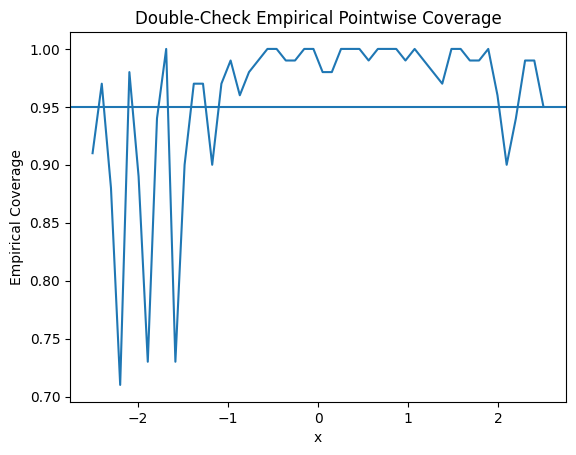

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 改成你真实路径
base_dir = r"C:\Users\yangy\26 spring\double check\doublecheck_outputs"

files = [f for f in os.listdir(base_dir) if f.endswith("_doublecheck.csv")]
files.sort()

print(f"Found {len(files)} replication files.")

all_indicators = []
x_reference = None

for fname in files:
    df = pd.read_csv(os.path.join(base_dir, fname))
    
    if x_reference is None:
        x_reference = df["x"].values
    
    all_indicators.append(df["cov_indicator"].values)

all_indicators = np.array(all_indicators)

print("Indicator matrix shape:", all_indicators.shape)

coverage_curve = all_indicators.mean(axis=0)

print("Overall mean coverage:", coverage_curve.mean())

plt.figure()
plt.plot(x_reference, coverage_curve)
plt.axhline(0.95)
plt.xlabel("x")
plt.ylabel("Empirical Coverage")
plt.title("Double-Check Empirical Pointwise Coverage")
plt.show()
